In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.optimize import fsolve
import numpy as np

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is not available


In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol

    def forward(self, time, temperature, loading, rho_m0=1.0e12):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
            rho_m0 (float): initial dislocation density (m^-2). Must be > 0 to seed
                            plastic flow via the Orowan equation. Default: 1e12 m^-2.
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup forces
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Seed rho_m in state0; all other state variables start at zero.
        # assemble_by_variable zero-fills any variables not provided.
        # forces shape: (ntime, nbatch, nforces), so forces.shape[1:-1] == (nbatch,)
        nbatch_shape = forces.shape[1:-1]
        rho_m_seed = torch.full(nbatch_shape + (1,), rho_m0, device=forces.device, dtype=forces.dtype)
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {"state/internal/rho_m": rho_m_seed}
        ).torch()
        
        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]


In [9]:
nchunk = 50
nmodel = neml2.load_model("new_model_tensile.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_X", "E_Y", "elasticity_nu", "C_X", "g_X", "athermal_L", "athermal_b", "flow_rate_b", "rho_m_rate_L", "shear_athermal_m", "shear_eff_m",
                                                                            "sy_X", "v_disl_Bk", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_pierls_stress", "G_X", "G_Y", "v_disl_p", "v_disl_q", "k1_X", "k2_X",
                                                                            "athermal_alpha", "v_disl_T_ref", "v_disl_Bk", "v_disl_k_B", "v_disl_activation_energy", "T_0_X", "T_ref_X"]), nchunk=nchunk)

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/gamma [Scalar]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/gamma [Scalar]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/gamma [Scalar]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: C_X [Scalar][Double][cpu]
            C_Y [Scalar][Double][cpu]
            E_X [Scalar][Double][cpu]
        

In [6]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.C_Y: tensor([200.]), torch.Size([1])

discrete_equations.T_0_Y: tensor([698.5200]), torch.Size([1])

discrete_equations.T_ref_Y: tensor([873.1500]), torch.Size([1])

discrete_equations.g_Y: tensor([10.]), torch.Size([1])

discrete_equations.k1_Y: tensor([1.]), torch.Size([1])

discrete_equations.k2_Y: tensor([10.]), torch.Size([1])

discrete_equations.sy_Y: tensor([500.]), torch.Size([1])



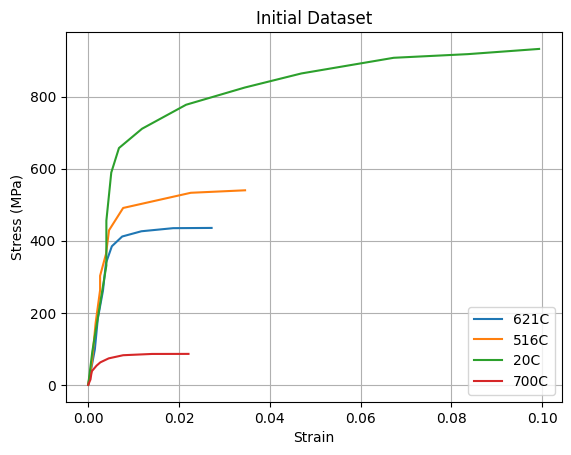

In [7]:
# Load experimental data
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/HT9_var_temp_and_erate'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if 'RT' in filename:
            temp_label = '20'
        elif '516' in filename:
            temp_label = '516'
        elif '621' in filename:
            temp_label = '621'
        elif '700' in filename:
            temp_label = '700'
        else:
            temp_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{temp_label}_strain', 'y':f'{temp_label}_stress'})
        data_frames[temp_label] = new_df

strain_data = {}
stress_data = {}

for temp_label, df in data_frames.items():
    strain_col = f'{temp_label}_strain'
    stress_col = f'{temp_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[temp_label] = strain
    stress_data[temp_label] = stress

# Plot initial dataset
plt.figure()
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), label=f"{temp_label}C")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Initial Dataset')
plt.grid()
plt.legend()
plt.show()

In [8]:
nrate = 4
ntemperature = 4
nbatch = 4
ntime = 100
rates = torch.tensor([1.0e-4, 4.0e-5, 4.0e-3, 1.38e-6], device=device)
# Temperatures in Kelvin (required by k_B = 8.617e-5 eV/K in the thermally activated mobility model)
temperatures = torch.tensor([293.15, 789.15, 894.15, 973.15], device=device)
print(f"--- Initial Experimental Conditions ---\nstrain rates:\n{rates}\ntemperatures (K):\n{temperatures}")


--- Initial Experimental Conditions ---
strain rates:
tensor([1.0000e-04, 4.0000e-05, 4.0000e-03, 1.3800e-06])
temperatures (K):
tensor([293.1500, 789.1500, 894.1500, 973.1500])


In [8]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, T in enumerate(temperatures):
    # t_label uses Celsius for dict lookup (data was loaded with Celsius keys)
    t_label = str(int(T.item() - 273))
    # Get the actual strain range from experimental data
    min_strain = strain_data[t_label].min().item()
    max_strain = strain_data[t_label].max().item()
    
    print(f"Temperature {t_label}C ({T.item():.2f}K): strain range [{min_strain:.4f}, {max_strain:.4f}]")
    print(f'{rates[i].item()}')
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rates[i].item(), ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


Temperature 20C (293.15K): strain range [0.0000, 0.0993]
0.0001
Temperature 516C (789.15K): strain range [0.0000, 0.0346]
4e-05
Temperature 621C (894.15K): strain range [0.0000, 0.0272]
0.004
Temperature 700C (973.15K): strain range [0.0000, 0.0221]
1.38e-06

--- Full Input Tensors ---
time: torch.Size([100, 4, 1])
temperature: torch.Size([100, 4, 1])
loading: torch.Size([100, 4, 6])


Initial data size for 621: torch.Size([10])
Initial data size for 516: torch.Size([10])
Initial data size for 20: torch.Size([14])
Initial data size for 700: torch.Size([10])
Interpolated data shape:
strain: torch.Size([100, 4, 6])
stress: torch.Size([100, 4, 6])


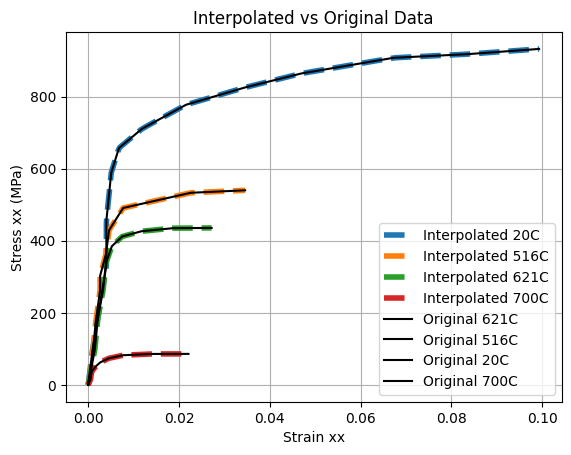

In [9]:
# Initial data shape
for temp_label in strain_data:
    print(f"Initial data size for {temp_label}: {stress_data[temp_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, T in enumerate(temperatures):
    # t_label in Celsius for dict lookup
    t_label = str(int(T.item() - 273))
    
    f_strain = torch.nn.functional.interpolate(strain_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {t_label}C")
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), color='k', label=f"Original {temp_label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


Temp 20C: E = 100000.00 MPa, E_exp = 101807.47 MPa
  Yield stress: 676.74 MPa at strain: 0.0086
Temp 516C: E = 68000.00 MPa, E_exp = 76634.31 MPa
  Yield stress: 492.91 MPa at strain: 0.0084
Temp 621C: E = 72000.00 MPa, E_exp = 67211.36 MPa
  Yield stress: 413.98 MPa at strain: 0.0082
Temp 700C: E = 66000.00 MPa, E_exp = 29890.25 MPa
  Yield stress: 73.25 MPa at strain: 0.0045


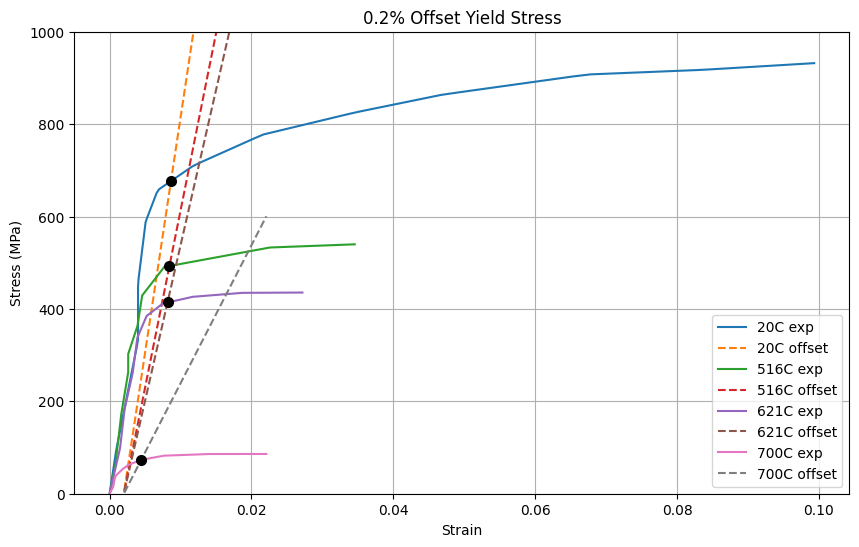


Experimental E values: [101807.46502653  76634.31232093  67211.3619677   29890.25012762]
Experimental sy values: [676.73816576 492.90807825 413.98290585  73.25199063]
Experimental G values: [39156.7173179  29474.73550805 25850.52383373 11496.25004908]
Updated E:  tensor([101807.4650,  76634.3123,  67211.3620,  29890.2501], device='cuda:0')
Updated sy: tensor([676.7382, 492.9081, 413.9829,  73.2520], device='cuda:0',
       requires_grad=True)
Updated G:  tensor([39156.7173, 29474.7355, 25850.5238, 11496.2500], device='cuda:0')


In [10]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch() # current Young's Modulus for model
sy = nmodel.sy_Y.tensor().clone().torch()
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item() - 273))  # Celsius label for display/lookup

    # Calculate actual experimental Young's Modulus
    strain_initial = exp_strain_data[:5, i, 0].cpu().numpy()
    stress_initial = exp_stress_data[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

    # Grab experimental data (keep on GPU)
    stress_exp = exp_stress_data[:, i, 0]
    strain_range = exp_strain_data[:, i, 0]

    # Build 0.2% offset line: E * (strain - 0.002), zero below offset
    valid_idx = strain_range >= offset
    stress_offset = torch.zeros_like(strain_range)
    stress_offset[valid_idx] = E_exp * (strain_range[valid_idx] - offset)

    # Find yield point: first sign change of (stress_exp - stress_offset) in valid region
    diff = stress_exp - stress_offset
    diff_valid = diff[valid_idx]
    strain_valid = strain_range[valid_idx]
    stress_valid = stress_exp[valid_idx]

    sign_changes = torch.where(torch.diff(torch.sign(diff_valid)) != 0)[0]

    if len(sign_changes) > 0:
        idx = sign_changes[0].item()
        # Linear interpolation between the two bracketing points
        d0, d1 = diff_valid[idx].item(), diff_valid[idx + 1].item()
        s0, s1 = strain_valid[idx].item(), strain_valid[idx + 1].item()
        se0, se1 = stress_valid[idx].item(), stress_valid[idx + 1].item()

        t = d0 / (d0 - d1)  # interpolation parameter in [0, 1]
        yield_strain = s0 + t * (s1 - s0)
        yield_stress = se0 + t * (se1 - se0)

        sy_exps.append(yield_stress)
        print(f"  Yield stress: {yield_stress:.2f} MPa at strain: {yield_strain:.4f}")
        plt.plot(yield_strain, yield_stress, 'ko', markersize=7, zorder=5)
    else:
        print(f"  WARNING: No intersection found for {temp_label}C — check offset or data range")
        sy_exps.append(np.nan)

    # Plot experimental curve and offset line
    plt.plot(strain_range.cpu().numpy(), stress_exp.cpu().numpy(), '-', label=f"{temp_label}C exp")
    plt.plot(strain_range[valid_idx].cpu().numpy(), stress_offset[valid_idx].cpu().numpy(),
             '--', label=f"{temp_label}C offset")

plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('0.2% Offset Yield Stress')
plt.legend()
plt.grid()
plt.ylim((0.0, 1000.0))
plt.show()

# Replace model parameters with experimental values to improve training
E_exps = np.array(E_exps)
sy_exps = np.array(sy_exps)

# Compute G from experimental E: G = E / (2*(1+nu))
G_exps = E_exps / (2.0 * (1.0 + nu.cpu().numpy()))

print(f"\nExperimental E values: {E_exps}")
print(f"Experimental sy values: {sy_exps}")
print(f"Experimental G values: {G_exps}")

E_tensor  = torch.tensor(E_exps, device=device, dtype=torch.double)
sy_tensor = torch.tensor(sy_exps[~np.isnan(sy_exps)], device=device, dtype=torch.double)
G_tensor  = torch.tensor(G_exps, device=device, dtype=torch.double)

with torch.no_grad():
    E_param  = nmodel.E_Y.tensor().torch()
    sy_param = nmodel.sy_Y.tensor().torch()
    G_param = nmodel.G_Y.tensor().torch()
    E_param.copy_(E_tensor)
    sy_param.copy_(sy_tensor)
    G_param.copy_(G_tensor)
    print(f"Updated E:  {nmodel.E_Y.tensor().torch()}")
    print(f"Updated sy: {nmodel.sy_Y.tensor().torch()}")
    print(f"Updated G:  {nmodel.G_Y.tensor().torch()}")


In [11]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(f"{stress}")

/home/colinmoose/miniforge/envs/neml2/lib/python3.13/site-packages/pyzag/chunktime.py:114: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


tensor([[[0.0000e+00],
         [0.0000e+00],
         [0.0000e+00],
         [0.0000e+00]],

        [[1.0214e+02],
         [2.6748e+01],
         [1.8454e+01],
         [6.7742e+00]],

        [[2.0428e+02],
         [5.3497e+01],
         [3.6908e+01],
         [1.3548e+01]],

        [[3.0641e+02],
         [8.0245e+01],
         [5.5362e+01],
         [2.0323e+01]],

        [[4.0855e+02],
         [1.0699e+02],
         [7.3816e+01],
         [2.7097e+01]],

        [[5.1069e+02],
         [1.3374e+02],
         [9.2270e+01],
         [3.3871e+01]],

        [[6.1283e+02],
         [1.6049e+02],
         [1.1072e+02],
         [4.0645e+01]],

        [[7.1497e+02],
         [1.8724e+02],
         [1.2918e+02],
         [4.7419e+01]],

        [[8.1710e+02],
         [2.1399e+02],
         [1.4763e+02],
         [5.4193e+01]],

        [[9.1924e+02],
         [2.4073e+02],
         [1.6609e+02],
         [6.0968e+01]],

        [[1.0214e+03],
         [2.6748e+02],
         [1.84

Text(0.5, 1.0, 'Initial Comparison')

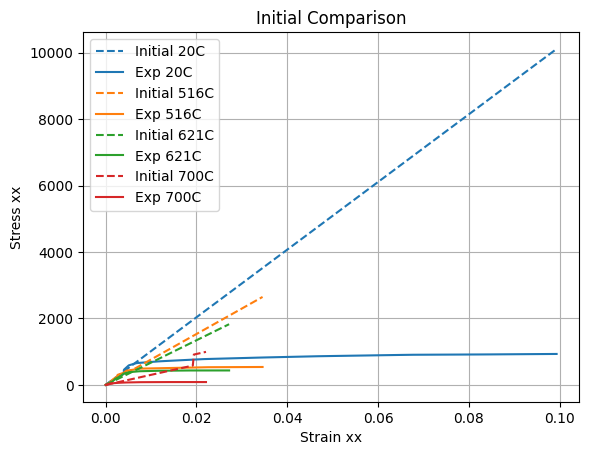

In [12]:
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))  # Celsius label for display
    plt.plot(loading[:, i, 0].detach().cpu(), stress[:, i, 0].detach().cpu(), '--', color=f'C{i}',label=f"Initial {t_label}C")
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), color=f'C{i}',label=f'Exp {t_label}C')
plt.xlabel("Strain xx")
plt.ylabel("Stress xx")
plt.legend()

plt.grid()
plt.title("Initial Comparison")
